# 📌 Project Title-
# Online Retail Data Analysis

## 📖 Introduction

#### This dataset contains transactional data from an online retail store, including invoice details, product descriptions, quantities purchased, unit prices, customer IDs, and country information. Each row represents a product purchased within a specific invoice.

#### The dataset is useful for analyzing customer purchasing patterns, sales performance, and product demand trends. It helps in understanding how different customers interact with products across various regions and time periods.

#### Such datasets are commonly used in business analytics and data science projects to extract insights that can support decision-making in marketing, inventory management, and customer segmentation.

## 🎯 Objective

#### The main objectives of this project are:

#### To analyze sales transactions and understand purchasing behavior of customers.
#### To identify top-selling products based on quantity and revenue.
#### To study customer distribution across different countries.
#### To perform time-based analysis of sales trends using invoice dates.
#### To compute total revenue generated from transactions.
#### To support business decisions such as inventory planning and marketing strategies through data insights.

## Steps Performed
#### 1.Import Libraries
#### 2.Load dataset
#### 3.Understand Dataset Structure
#### 4.Data Cleaning
#### 5.Create Revenue Column
#### 6.Top 10 Products by Revenue
#### 7.Country-wise Sales Analysis
#### 8.Monthly Sales Trend
#### 9.Quantity vs Revenue Relationship
#### 10.Customer Distribution by Country
#### 11. Correlation Heatmap

## Step-1 Import Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step-2 Load dataset

In [16]:
df = pd.read_excel(r"C:\Users\abhit\Downloads\online+retail\Online Retail.xlsx")

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## STEP 3 – Understand Dataset Structure

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## STEP 4 – Data Cleaning

#### Remove product returns (negative quantity)

In [20]:
df = df[df["Quantity"] > 0]

#### Remove zero price rows

In [21]:
df = df[df["UnitPrice"] > 0]

#### Remove missing product names

In [22]:
df = df.dropna(subset=["Description"])

#### Convert InvoiceDate to proper date format

In [23]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## STEP 5 – Create Revenue Column

In [24]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

## STEP 6 – Top 10 Products by Revenue

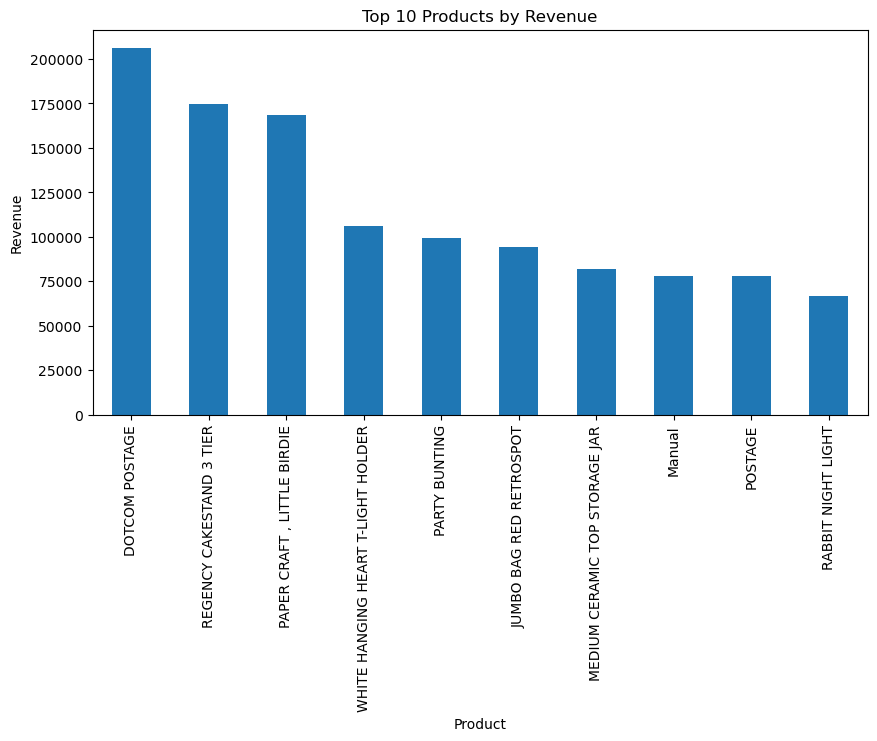

In [25]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.show()

#### Insight

#### Which products generate highest revenue?

## STEP 7 – Country-wise Sales Analysis

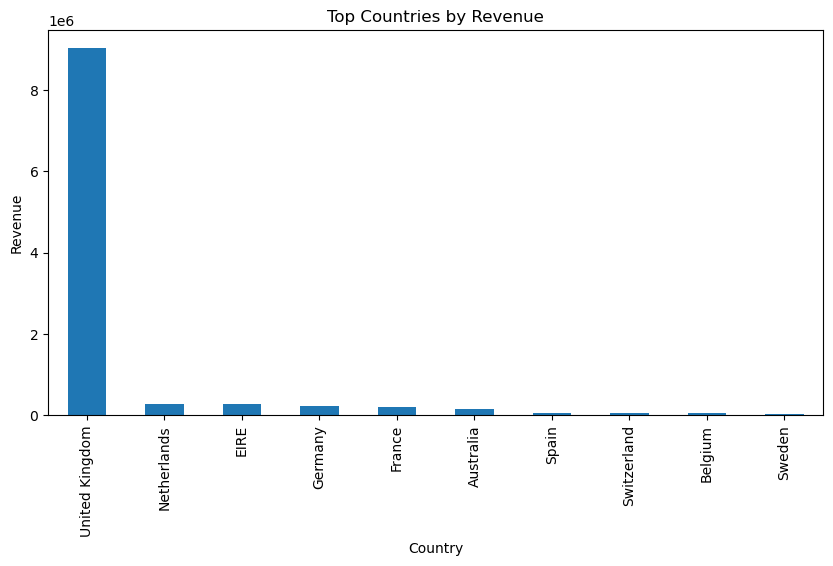

In [26]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

country_sales.plot(kind="bar")

plt.title("Top Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.show()

#### Insight

#### Which country contributes most sales.

## STEP 8 – Monthly Sales Trend

In [27]:
## Create month column 
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [28]:
## Calculate monthly revenue:
monthly_sales = df.groupby("Month")["Revenue"].sum()

## STEP 9 – Quantity vs Revenue Relationship

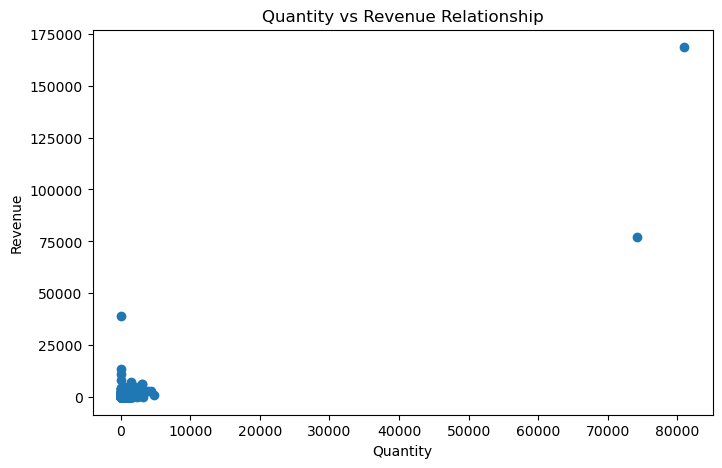

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(df["Quantity"], df["Revenue"])

plt.title("Quantity vs Revenue Relationship")

plt.xlabel("Quantity")

plt.ylabel("Revenue")

plt.show()

## STEP 10 – Customer Distribution by Country

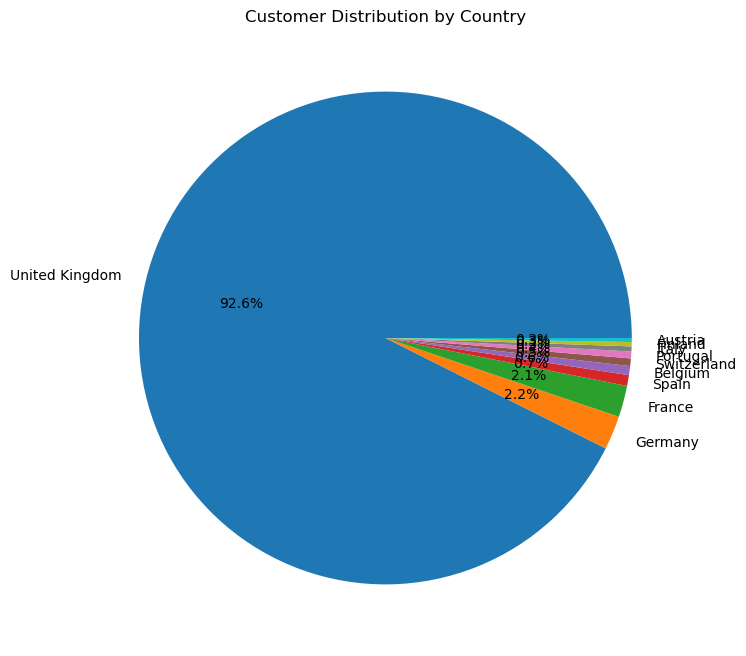

In [30]:
customer_dist = df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))

customer_dist.plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Distribution by Country")

plt.ylabel("")

plt.show()

#### Insight

#### Shows where most customers belong.

## STEP 11 – Correlation Heatmap

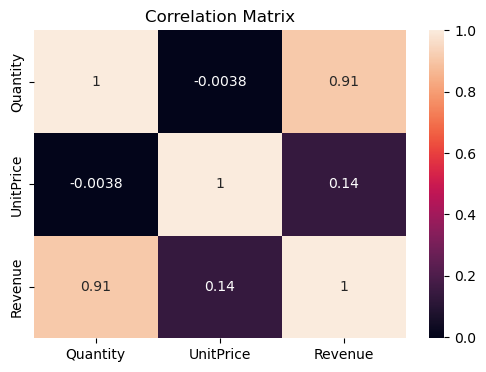

In [31]:
plt.figure(figsize=(6,4))

sns.heatmap(df[["Quantity","UnitPrice","Revenue"]].corr(),
            annot=True)

plt.title("Correlation Matrix")

plt.show()

### Seasonal Pattern (Month-wise Comparison)

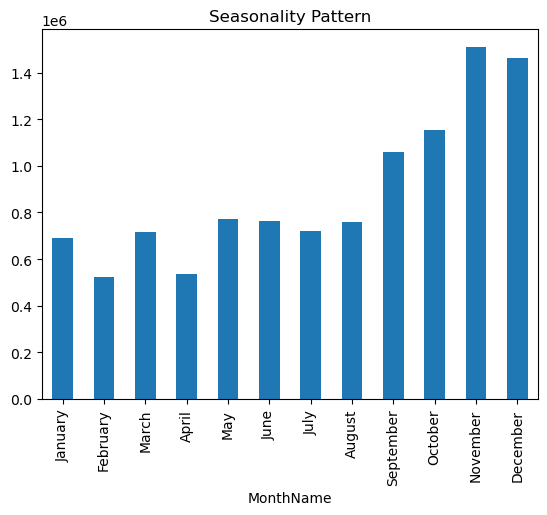

In [32]:
df["MonthName"] = df["InvoiceDate"].dt.month_name()

month_pattern = df.groupby("MonthName")["Revenue"].sum()

month_pattern = month_pattern.reindex([
"January","February","March","April","May","June",
"July","August","September","October","November","December"
])

month_pattern.plot(kind="bar")

plt.title("Seasonality Pattern")

plt.show()

### Average Order Value

In [33]:
avg_order_value = df.groupby("InvoiceNo")["Revenue"].sum().mean()

avg_order_value

534.403033266533

### High Value Customers

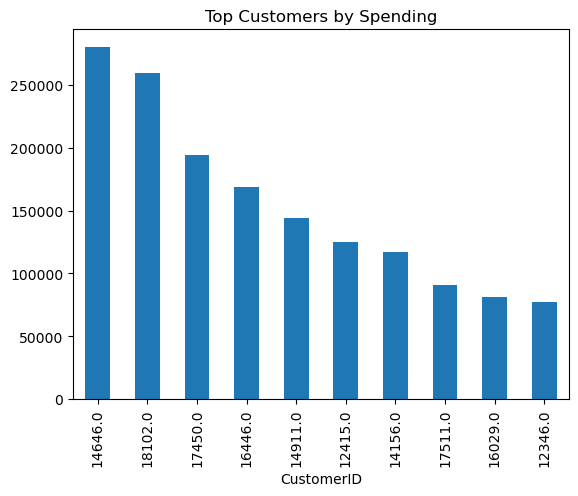

In [34]:
customer_value = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)

customer_value.plot(kind="bar")

plt.title("Top Customers by Spending")

plt.show()

### Distribution of Unit Price

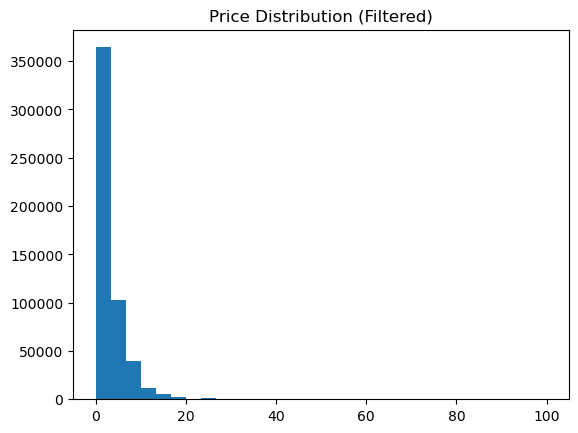

In [38]:
df_price = df[df["UnitPrice"] < 100]

plt.hist(df_price["UnitPrice"], bins=30)

plt.title("Price Distribution (Filtered)")

plt.show()     ## x - quantity and y - price 

### Top Product Categories (based on keywords)

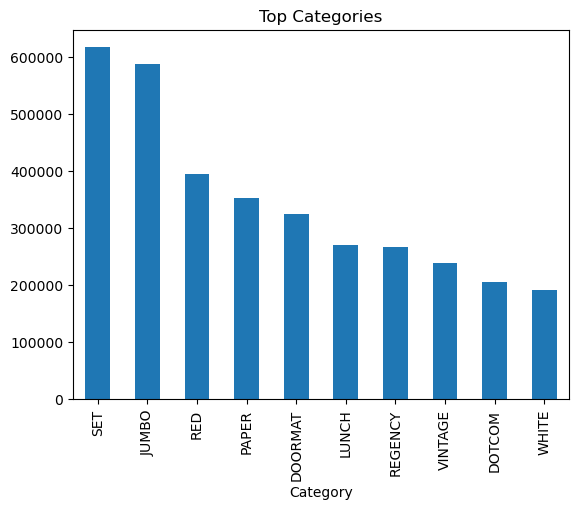

In [37]:
##Example grouping by keywords:
df["Category"] = df["Description"].str.split().str[0]

category_sales = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(10)

category_sales.plot(kind="bar")

plt.title("Top Categories")

plt.show()

### Storytelling Summary

In [44]:
from IPython.display import display, HTML

html_content = """
<span style="color: blue;">
<ul>
    <li>Few products generate most revenue</li>
    <li>Some countries have more customers</li>
    <li>Sales show seasonal pattern</li>
    <li>High quantity does not always mean high revenue</li>
    <li>Few customers contribute large revenue</li>
    <li>Price impacts revenue</li>
</ul>
</span>
"""

display(HTML(html_content))